Exploratory data analysis of images and metadata from *Automating the assessment of biofouling in images using expert agreement as a gold standard* by Mannix, Wei, Woodham, Wilkinson, & Robinson.

In [2]:
import pandas as pd
import imageio.v2 as imageio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import skimage.measure
import time

data_dir = 'data-biofouling/'
image_dir = 'data-biofouling/images/'
metadata_filename = 'metadata.csv'

In [3]:
# Loading the metadata csv file
df = pd.read_csv(data_dir + metadata_filename)
df.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training


In [4]:
len(df)

10263

In [5]:
df.describe()

,vessel.id,SLoF,paint.quality
count,10263.000000,10263.000000,10263.000000
mean,158.917568,0.310436,1.860372
std,103.249300,0.599401,0.771680
min,1.000000,0.000000,1.000000
25%,64.000000,0.000000,1.000000
50%,147.000000,0.000000,2.000000
75%,272.000000,0.000000,2.000000
max,308.000000,2.000000,3.000000


Text(0, 0.5, '')

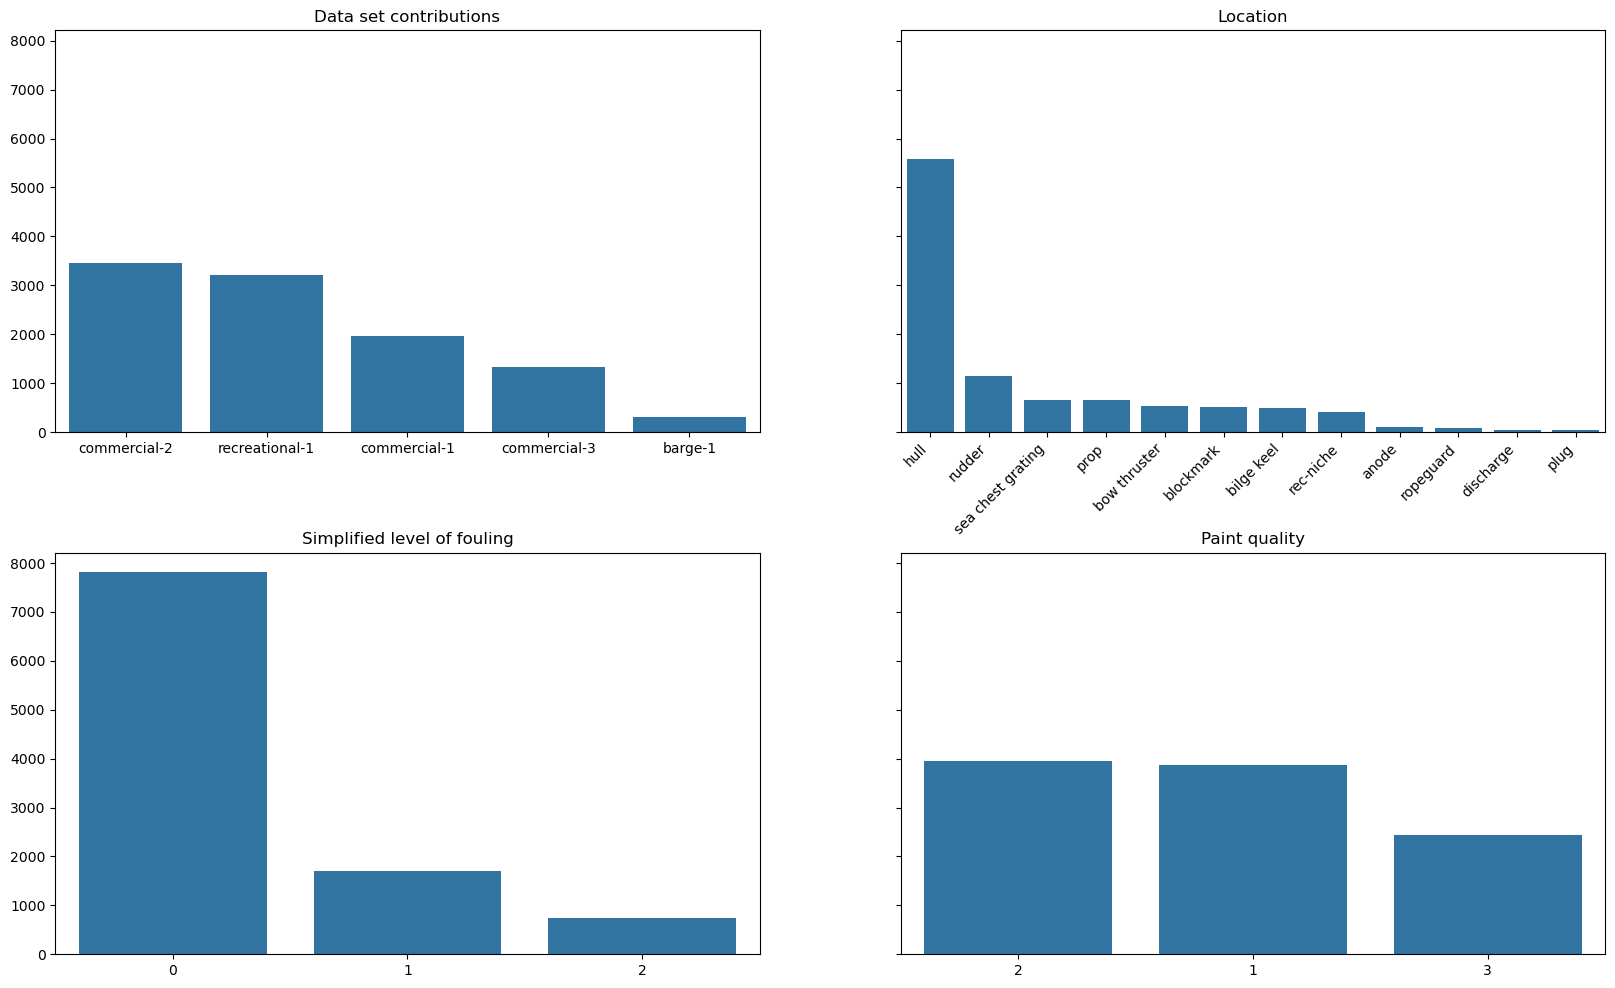

In [6]:
# Visualize distributions for dataset.name, niche.area, SLoF, and paint.quality
fig, axes = plt.subplots(2, 2, figsize = (20,12), sharey=True)
axes = axes.flatten()
plt.subplots_adjust(hspace = 0.3)

# dataset.name
i = 0
column_name = 'dataset.name'
counts = df[column_name].value_counts()
order = counts.index
sns.countplot(x=column_name, data=df, ax=axes[i], order=order)
axes[i].set_title('Data set contributions')
axes[i].set_xlabel('')
axes[i].set_ylabel('')

# niche.area
i += 1
column_name = 'niche.area'
counts = df[column_name].value_counts()
order = counts.index
sns.countplot(x=column_name, data=df, ax=axes[i], order=order)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[i].set_title('Location')
axes[i].set_xlabel('')
axes[i].set_ylabel('')

# simplified level of fouling (SLoF)
i += 1
column_name = 'SLoF'
counts = df[column_name].value_counts()
order = counts.index
sns.countplot(x=column_name, data=df, ax=axes[i], order=order)
axes[i].set_title('Simplified level of fouling')
axes[i].set_xlabel('')
axes[i].set_ylabel('')

# paint.quality
i += 1
column_name = 'paint.quality'
counts = df[column_name].value_counts()
order = counts.index
sns.countplot(x=column_name, data=df, ax=axes[i], order=order)
axes[i].set_title('Paint quality')
axes[i].set_xlabel('')
axes[i].set_ylabel('')

In [7]:
df['split'].value_counts()

split
training      9422
validation     841
Name: count, dtype: int64

In [8]:
df_train = df[df['split'] == 'training']
df_val = df[df['split'] == 'validation']

In [9]:
len(df_train)

9422

In [10]:
# numerically encode categorical variables so that we can make a correlation matrix
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=["object", "category"]):
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [11]:
df_encoded.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split
0,0,1,8,5,0,3,0
1,1,1,8,5,0,3,0
2,2,1,8,5,0,2,0
3,3,1,8,5,0,2,0
4,4,1,8,5,0,3,0


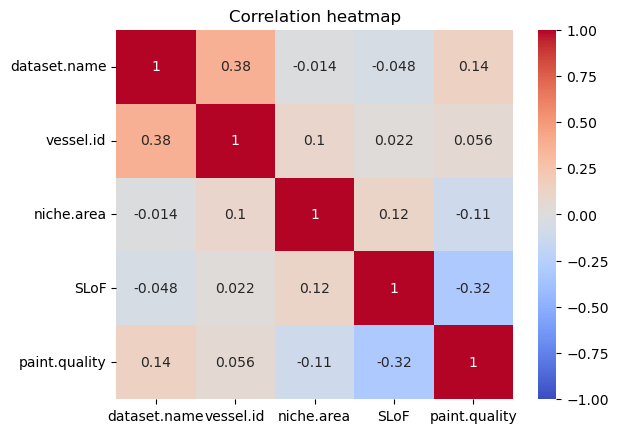

In [12]:
# drop the image.name and split variables before making a correlation matrix
df_smaller = df_encoded.drop(['image.name','split'], axis=1)

# make a correlation heatmap
corr = df_smaller.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()

As you can see from the correlation heatmap, none of these variables meaningfully correlates with SLoF.

In [14]:
# Load all of the images
image_filenames = df['image.name']
images = {}
for filename in image_filenames:
    images[filename] = imageio.imread(image_dir + filename)

In [15]:
# Some ways to measure complexity of an image
# -shannon entropy, implemented in skimage.shannon_entropy
# -gradient_energy, implemented below
# -variance of red/green/blue channels

def gradient_energy(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    gx, gy = np.gradient(img.astype(float))
    return np.mean(np.sqrt(gx**2 + gy**2))

def laplacian_variance(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    lap = -4*img + np.roll(img, 1, 0) + np.roll(img, -1, 0) + np.roll(img, 1, 1) + np.roll(img, -1, 1)
    return lap.var()

def channel_variances(img):
    # (red, green, blue)
    variances = np.var(img, axis=(0, 1)) 
    return tuple(variances)

In [16]:
# make an enlarged dataframe including the complexity metrics

entropy_list = []
gradient_energy_list = []
laplacian_variance_list = []
red_variance_list = []
green_variance_list = []
blue_variance_list = []

#j = 0
#total = len(image_filenames)
#t_0 = time.time()

for filename in image_filenames:
    img = images[filename]
    entropy_list.append(skimage.measure.shannon_entropy(img))
    gradient_energy_list.append(gradient_energy(img))
    laplacian_variance_list.append(laplacian_variance(img))
    
    r_var, g_var, b_var = channel_variances(img)
    red_variance_list.append(r_var)
    green_variance_list.append(g_var)
    blue_variance_list.append(b_var)

#    j += 1
#    if j % 500 == 0:
#        print(f"Processed image {j} of {total}")
#        t_1 = time.time()
#        time_elapsed = t_1 - t_0
#        avg_time = time_elapsed / j
#        print(f"\tTime spent:", int(time_elapsed), "seconds")
#        print(f"\tEstimated time remaining:", int((total-j)*avg_time), 'seconds\n') 
    
df_aug = df.copy()
df_aug['entropy'] = entropy_list
df_aug['gradient_energy'] = gradient_energy_list
df_aug['laplacian_var'] = laplacian_variance_list
df_aug['red_var'] = red_variance_list
df_aug['green_var'] = green_variance_list
df_aug['blue_var'] = blue_variance_list

In [17]:
df_aug.head(5)

,image.name,dataset.name,vessel.id,niche.area,SLoF,paint.quality,split,entropy,gradient_energy,laplacian_var,red_var,green_var,blue_var
0,000001-GNZuCtwed3.jpg,commercial-1,8,hull,0,3,training,7.210319,4.478048,636.869978,1167.255624,1246.322851,908.185944
1,000002-CAgNlUizNm.jpg,commercial-1,8,hull,0,3,training,7.272785,5.438474,651.793542,1431.521255,1157.676356,896.145955
2,000003-vDe7GN0NrL.jpg,commercial-1,8,hull,0,2,training,6.754425,3.899760,672.922542,726.176904,2836.436721,3370.453269
3,000004-TbUBpfn6iP.jpg,commercial-1,8,hull,0,2,training,6.805911,3.346528,638.983190,1927.794439,800.957564,610.556934
4,000005-oemYWm1Tjg.jpg,commercial-1,8,hull,0,3,training,7.596727,5.017859,816.255540,3071.784278,4140.360718,4639.516300


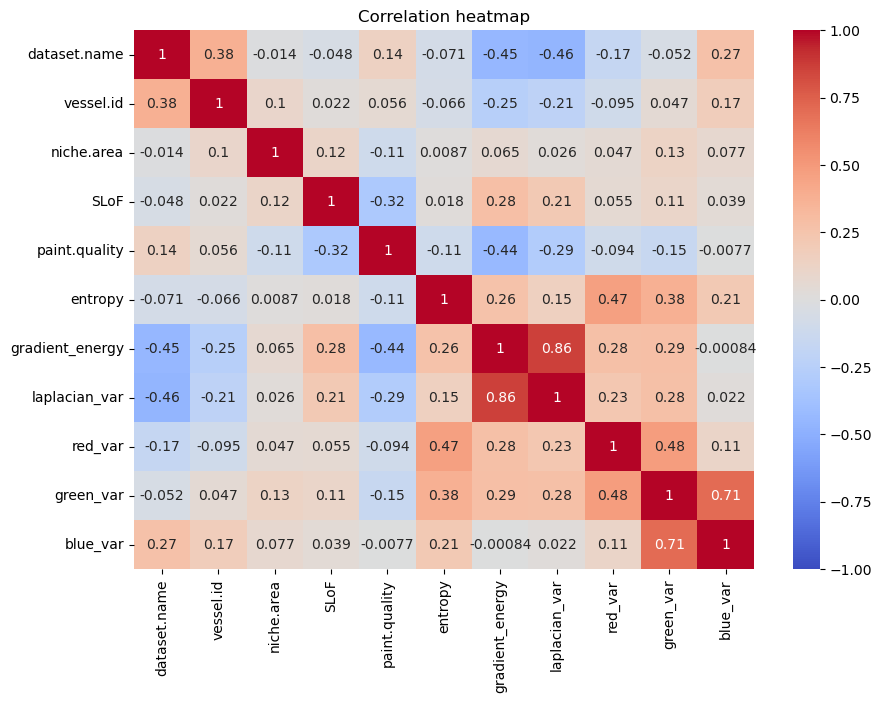

In [18]:
# making a new correlation matrix with metric columns

# drop the image.name and split variables
df_smaller = df_aug.drop(['image.name','split'], axis=1)

# encode the remaining non-numeric variables
df_encoded = df_smaller.copy()
for col in df_encoded.select_dtypes(include=["object", "category"]):
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# make a correlation heatmap
corr = df_encoded.corr()
plt.figure(figsize = (10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()

The highest correlation with SLoF seems to be gradient entropy, though it is still quite a weak correlation.

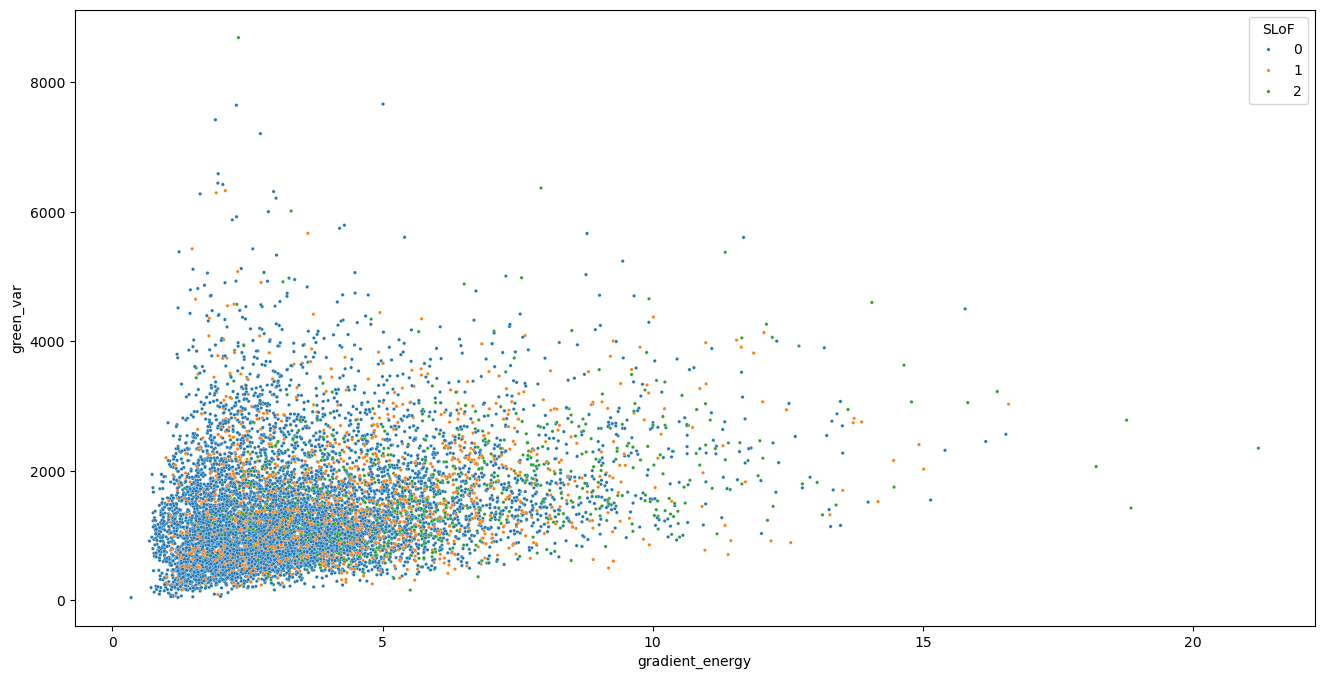

In [20]:
plt.figure(figsize = (16,8))
sns.scatterplot(data=df_aug, x='gradient_energy', y='green_var', hue='SLoF', palette='tab10', s=6)
plt.show()

In [21]:
def display_channels(img):
    
    # Create red, green, blue only versions
    red_only = img.copy()
    red_only[:, :, 1] = 0
    red_only[:, :, 2] = 0
    
    green_only = img.copy()
    green_only[:, :, 0] = 0
    green_only[:, :, 2] = 0
    
    blue_only = img.copy()
    blue_only[:, :, 0] = 0
    blue_only[:, :, 1] = 0
    
    # Plotting in one horizontal line
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))  # 1 row, 4 columns
    
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(red_only)
    axes[1].set_title("Red only")
    axes[1].axis("off")
    
    axes[2].imshow(green_only)
    axes[2].set_title("Green only")
    axes[2].axis("off")
    
    axes[3].imshow(blue_only)
    axes[3].set_title("Blue only")
    axes[3].axis("off")
    
    plt.tight_layout()
    plt.show()

In [22]:
def display_metrics(image):
    r_var, g_var, b_var = channel_variances(image)
    print("Red variance:", r_var)
    print("Green variance:", g_var)
    print("Blue variance:", b_var)
    print("Shannon entropy:", skimage.measure.shannon_entropy(image))
    print("Gradient energy:", gradient_energy(image))
    print("Laplacian variance:", laplacian_variance(image))

In [23]:
def load_and_analyze(image_index):
    image_filename = df.iloc[image_index]['image.name']
    image_as_array = images[image_filename]
    img = imageio.imread(image_dir + image_filename)
    display_channels(img)
    display_metrics(image_as_array)    

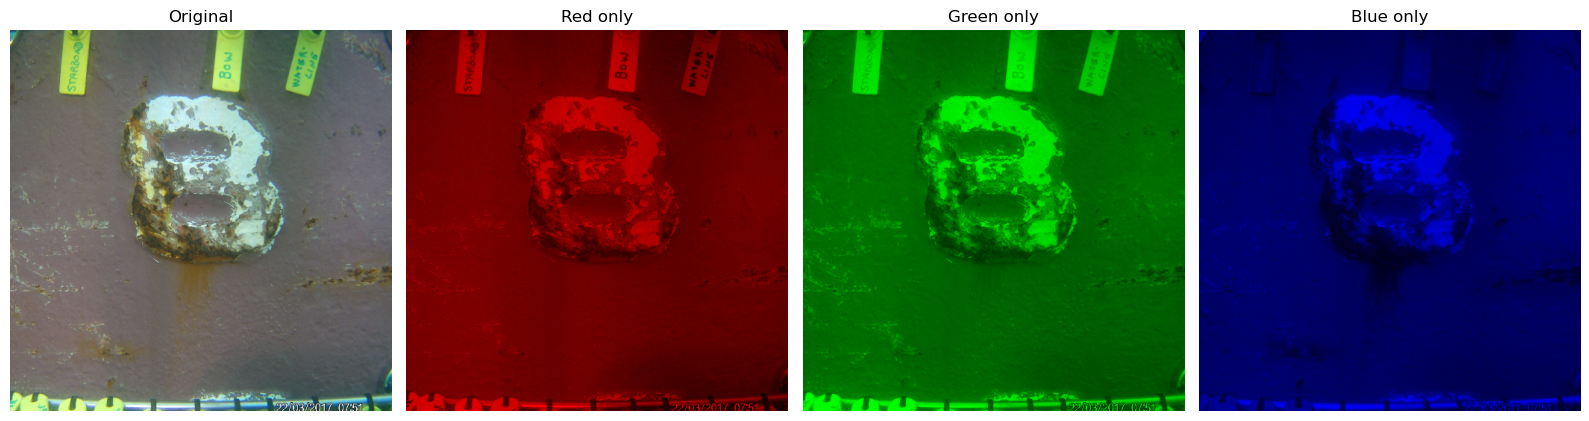

Red variance: 812.2214721420851
Green variance: 1383.4635356849349
Blue variance: 1018.0362173461465
Shannon entropy: 6.513313935081853
Gradient energy: 4.871409459071772
Laplacian variance: 764.7819069756403


In [24]:
load_and_analyze(image_index = 100)